<a href="https://colab.research.google.com/github/kuzovkov/neural-university/blob/main/%D0%9F%D1%80%D0%BE%D0%B4%D0%B2%D0%B8%D0%BD%D1%83%D1%82%D1%8B%D0%B9_%D0%B1%D0%BB%D0%BE%D0%BA_%7C_%D0%93%D0%B5%D0%BD%D0%B5%D1%80%D0%B0%D1%82%D0%B8%D0%B2%D0%BD%D0%BE_%D1%81%D0%BE%D1%81%D1%82%D1%8F%D0%B7%D0%B0%D1%82%D0%B5%D0%BB%D1%8C%D0%BD%D1%8B%D0%B5_%D1%81%D0%B5%D1%82%D0%B8_(%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D0%BA%D0%B0_2)_%7C_%D0%A3%D0%98%D0%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Содержание темы**

1. [Теория](https://colab.research.google.com/drive/1xt0WGrjMN_td_JidPfea-5C-411y_TJG?usp=sharing)

2. [Практика 1](https://colab.research.google.com/drive/1TxsZI7Wetzp1IqMaeE1DsVGuIM8RJ8zq?usp=sharing)

3. Практика 2



# Conditional GAN (CGAN) (Генератор с условием)

Из того, что мы узнали ранее про GAN мы понимаем, что GAN'ы генерируют изображения произвольно. Т.е. мы не можем влиять на то, какое изображение в данный момент будет генерировать Генератор. Чтобы исправить этот момент, можно использовать GAN с условием - CGAN (Conditional Generative Adverserial Network), она же генеративно-состязательная сеть с условием.

Для того что обычный GAN превратить в CGAN нам достаточно сделать один простой трюк, а именно добавить метки или лэйблы к данным на которых обучается наш GAN. Вот как это выглядит:

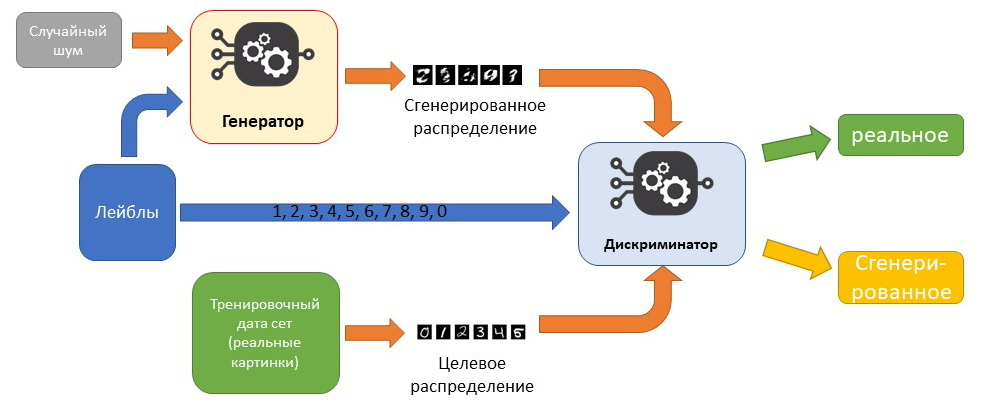

В случае с MNIST, лейблами к картинкам выступают сами цифры. Т.е. к изображению нуля лейблом будет цифра 0, к единице цифра 1 и т.д.
После обучения генератора в таком ключе, когда мы захотим сгенерировать конкретное изображение, на его вход вместе с шумом мы подадим соответствующий лейбл.

Рассмотрим на примере базы MNIST с лейблами:

In [ ]:
# Загрузка библиотек

# Базовые слои keras
from tensorflow.keras.layers import Input, Dense, Reshape, Flatten, Dropout

from tensorflow.keras.layers import BatchNormalization, Activation, MaxPooling2D, concatenate, Embedding, multiply, Conv2DTranspose, Concatenate

# Активационная функция
from tensorflow.keras.layers import LeakyReLU

# Светочные слои keras
from tensorflow.keras.layers import UpSampling2D, Conv2D

# Формат модели keras
from tensorflow.keras.models import Sequential, Model

# Утилиты
from tensorflow.keras.utils import plot_model

# Оптимизатор
from tensorflow.keras.optimizers.legacy import Adam

# модуль с датасетами
from tensorflow.keras.datasets import mnist, cifar10, fashion_mnist

# Библиотека для отрисовки графиков
import matplotlib.pyplot as plt

import sys
import random
# Numpy массивы
import numpy as np

# модуль для отрисовки изображения
from PIL import Image

In [ ]:
# Загружаем в X_train изображения рукописных цифр из mnist
(x_train, train_labels), (_, _) = mnist.load_data()

print(x_train.shape)

# масштабируем данные от -1 до 1
x_train = x_train / 127.5 - 1. # Нормализуем изображение от [-1,1]
x_train = np.expand_dims(x_train, axis=3) # Добавляем размерность для x_train ((28,28) => (28,28,1))
print(x_train.shape)

11501568/11490434 [==============================] - 0s 0us/step
(60000, 28, 28)
(60000, 28, 28, 1)


In [ ]:
train_labels[:10]

array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4], dtype=uint8)

### Создаем модели Генератора и дискриминатора

In [ ]:
# Определяем параметры

img_hieght = 28     # высота изображения
img_width = 28      # ширина изображения
channels = 1        # канал 1 (картинка черно белая)
img_shape = (img_hieght, img_width, channels)

random_vec = 100    # Задаем размер N-мерного вектора
dropout_rait = 0.1  # Задаем размер Dropout

batch_size = 128
n_classes = 10

In [ ]:
def create_cc_generator(random_vec,
                        n_classes):

  noise = Input(shape=(random_vec,)) # Создаем вход размером random_vec - вектор со случайным номрмальным распределением - шум
  labels_in = Input(shape=(1,)) # Создаем вход для лейблов
  labels = Embedding(n_classes, 10)(labels_in) # Преобразуем простые числа найходящиеся в train_labels в пространство embedding для подачи в нейросеть
  n_neurons = 7 * 7 # Основание для картинки 7х7
  labels = Dense(n_neurons)(labels)
  labels = Reshape((7,7,1))(labels) # Преобразуем вектора лейблов в тезоры для подачи в качестве дополнительного канала

  n_neurons = 128 * 7 * 7 # Указываем количество нейронов во входном слое 6272 --> 128 * 7 * 7
  gen = Dense(n_neurons)(noise) # Подаем шум на полносвязный слой, размер слоя выбран так, что бы его можно было преобразовать в удобный для нас размер
  gen = LeakyReLU(alpha=0.2) (gen) # Применяем активационную ф-ю LeakyReLU с параметром наклона 0.2
  #gen = BatchNormalization()(gen) # Добавляем слой нормализации
  gen = Reshape((7,7,128))(gen) # Преобразуем входящий вектор в тензор 6272 --> 128 * 7 * 7

  # Оъединяем изображение и его лейбл
  merge = multiply([gen, labels])

  gen = Conv2DTranspose(128,(4,4), strides=(2,2), padding='same')(merge) # Увеличиваем размерность до 14х14х128
  gen = LeakyReLU(alpha=0.2) (gen)
  #gen = BatchNormalization()(gen)
  gen = Conv2DTranspose(128,(4,4), strides=(2,2), padding='same')(gen)  # Увеличиваем размерность до 28х28х128
  gen = LeakyReLU(alpha=0.2) (gen)
  #gen = BatchNormalization()(gen)
  img = Conv2D(1,(7,7), activation = 'tanh', padding='same')(gen) # Преобразуем тензвор в картинку 28х28х1

  model = Model([noise,labels_in],img)
  return model

cc_gen = create_cc_generator(random_vec, n_classes) # создаем дискриминатор
cc_gen.summary() # выводем информацию о нейронной сети

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 100)]        0           []                               
                                                                                                  
 input_2 (InputLayer)           [(None, 1)]          0           []                               
                                                                                                  
 dense_1 (Dense)                (None, 6272)         633472      ['input_1[0][0]']                
                                                                                                  
 embedding (Embedding)          (None, 1, 10)        100         ['input_2[0][0]']                
                                                                                              

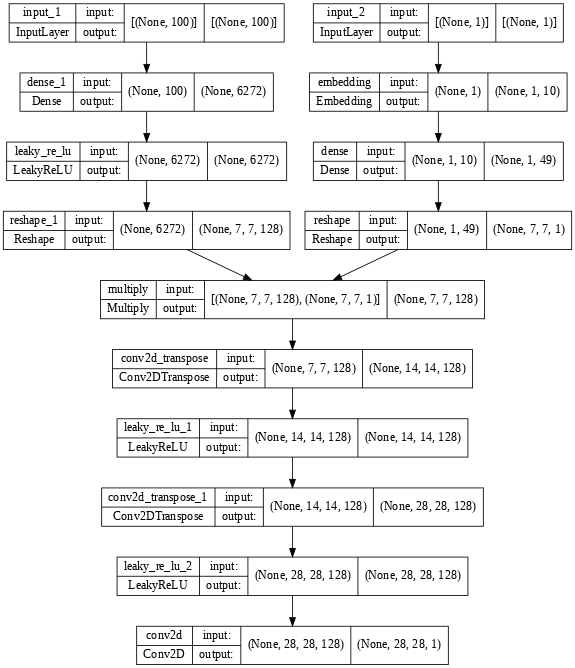

In [ ]:
plot_model(cc_gen, dpi = 60, show_shapes= True)

In [ ]:
def create_cc_discriminator(): # Функция создания сверточного дискрминатора

  img = Input(shape=img_shape) # Создаем вход на который поступает изоражение размером img_shape 28х28х1

  labels_in = Input(shape=(1,)) # Создаем вход для лейблов
  labels = Embedding(n_classes, 10)(labels_in) # Преобразуем простые числа найходящиеся в train_labels в пространство embedding для подачи в нейросеть
  labels = Dense(np.prod(img_shape))(labels) # Добавляем Dense-слой на  img_rows*img_cols*channels нейронов
  labels = Reshape((img_shape[0],img_shape[1],img_shape[2]))(labels) # Преобразуем вектора лейблов в тезоры для подачи в качестве дополнительного канала

  # Объединяем картинку и ее лейбл через функцию конкатенации
  merge = multiply([img, labels])

  dis = Conv2D(128, (3,3), strides=(2,2), padding='same')(merge) # Создаем слой  Conv2D, кол-во фильтров = 128, окно свертки = (3,3), шаг (2,2)
                                                               # на этом слое уменьшаем размерность 28х28х1 --> 14х14х128
  dis = LeakyReLU(alpha=0.2) (dis) # Применяем активационную ф-ю LeakyReLU с параметром наклона 0.2
  #dis = BatchNormalization()(dis) # Добавляем нормализацию
  dis = Conv2D(128, (3,3), strides=(2,2), padding='same')(dis) # Создаем слой  Conv2D, кол-во фильтров = 128, окно свертки = (3,3), шаг (2,2)
                                                               # на этом слое уменьшаем размерность 14х14х128 --> 7х7х128
  dis = LeakyReLU(alpha=0.2) (dis)
  #dis = BatchNormalization()(dis)
  dis = Flatten()(dis) # Вытягиваем тезор 7х7х128 в вектор длиной 6272
  dis = Dropout(0.4)(dis) # Добавляем слой Dropout с отсечкой в 40%
  classifier_layer = Dense(1, activation='sigmoid')(dis) # Выходной классифицирующий слой с активацией sigmoid

  cc_discriminator = Model([img, labels_in],classifier_layer)

 # Компилируем модель дискриманотра
  cc_discriminator.compile(loss='binary_crossentropy', # Компилируем модель, выбираем ф-ю ошибки бинраная кроссэнтропия
              optimizer=Adam(0.0002, 0.5), # Выбираем оптимизатор Адам с рекомендованными параметрами lr=0.0002, уменьшаем импульс β1 с 0.9 (по умолчанию)
                                           # до 0.5 что бы уменьшить колебания и увеличить стабильность обучения
              metrics=['accuracy'])

  cc_discriminator.trainable = False  # Замораживаем обучение дискриматора

  return cc_discriminator # Функция возвращает скомпилированный Дискриминатор

cc_discriminator = create_cc_discriminator()
cc_discriminator.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_4 (InputLayer)           [(None, 1)]          0           []                               
                                                                                                  
 embedding_1 (Embedding)        (None, 1, 10)        100         ['input_4[0][0]']                
                                                                                                  
 dense_2 (Dense)                (None, 1, 784)       8624        ['embedding_1[0][0]']            
                                                                                                  
 input_3 (InputLayer)           [(None, 28, 28, 1)]  0           []                               
                                                                                            

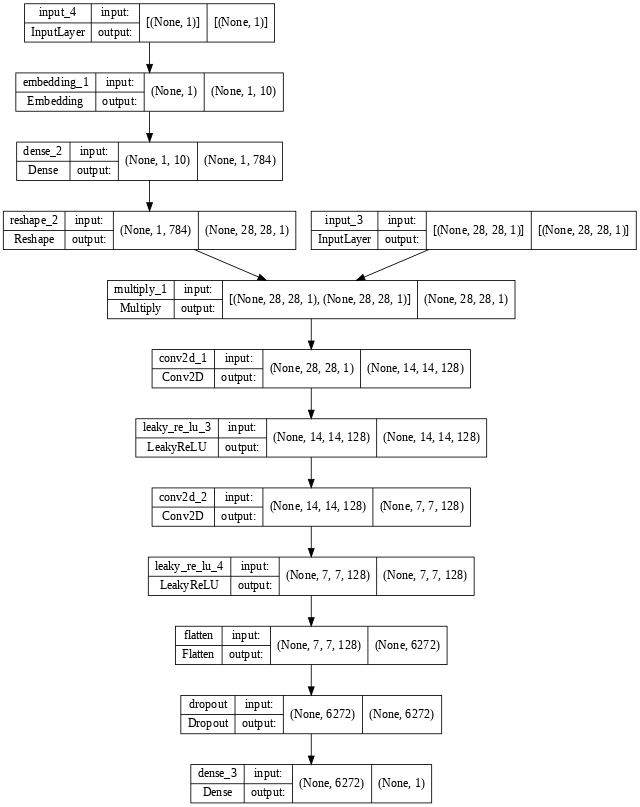

In [ ]:
plot_model(cc_discriminator, dpi = 60, show_shapes=True)

**Вспоминаем**. Чтобы работать с лейблами для нейросити нужно их преобразовать в One Hot Encoding или лбой другой удобный для нее вид. В данном примере мы используем Embedding слой для преобразования лейблов.

### Функция отисовки сгенерированных изображений

In [ ]:
def show_learning_proggress(gen):
  noise = np.random.normal(size=(1,random_vec)) # Генерируем случайный вектор с нормальным распределением
  sampled_labels = np.arange(0, 10).reshape(-1, 1) # Создаем массив меток от 0 до 10 и решейпим его в размерность (10, 1)
  fig = plt.figure(figsize=(15, 20)) # Задаем размер фигуры
  for i in range (10): # Перебираем по очереди все лейблы
    plt.subplot(1, 10, i+1) # Задаем количество изображений в полотне
    predict_gen = cc_gen.predict([noise,sampled_labels[i]], verbose = 0) #генерируем изображение из шума по заданному лейблу
    plt.imshow(predict_gen[0].reshape(28, 28), cmap='gray') # Выводим картинку на полотно
    plt.axis('off') # Отключаем оси
  plt.show() # Выводим все полотно на экран

## Состязательный алгоритм CGAN

In [ ]:
batch_size = 128

def CGAN_algoritm (generator,
                   discriminator,
                   epochs=30000,
                   batch_size=128):

   ''' Функция ...
       Args:

       Return:

   '''

   #создаем yTrain
   true_labels_img = np.ones((batch_size, 1)) # Создаем массив лэйблов с единицаами для истинного распределения (датасета с картинками)
   generated_labels_img = np.zeros((batch_size, 1)) # Сооздаем массив лэйблов с нулями для сгенерированного распределения (сгенерированные картинки)

   #Модель GAN собираем с помощью функционального программирования
   noise = Input (shape=(random_vec,))  # Создаем слой Input (Записываем входные данные рамерностью random_vec в noise)
   label = Input(shape=(1,)) # Создаем слой Input (Записываем входные данные рамерностью (1) в label)
   img = generator([noise, label]) # # Записываем в переменную img значение, возвращаемое generator'ом  с входным параметром noise
   checkup = discriminator([img, label]) # Записываем в переменную checkup значение, возвращаемое discriminator'ом с входным параметром img
                                # Дискриминатор возвращает вероятность того, что изображение поступившее к нему на вход отностися к одному из 2-х классов
   # Обратине внимание! В модели GAN generator и discriminator используются, так же как стандартные слои в моделях keras

   CGAN = Model([noise,label],checkup) # Собираем модель CGAN в которой обе модели G и D  входят как слои. На вход CGAN подаем вектор nois и лэйл, на выходе оценка вероятности
   CGAN.compile(loss='binary_crossentropy', optimizer = Adam(0.0002, 0.5))

   view_interval = 150 # интервал через который будем смотреть что получается

   d_loss_list = [] # лист значений ошибки дискриминатора
   g_loss_list = [] # лист значений ошибки генератора
   d_acc_list = [] # лист значений ошибки точность модели

   for epoch in range(epochs):

      # Формируем пакеты данных - Batch для Дискриминатора и Генератора

      # Для Дискриминатора batch формируется из истинного распределения вероятности (базы настоящих картинок)
      index = np.random.randint(0, x_train.shape[0], batch_size ) # генерируем случайные индексы в диапазоне x_train в количестве batch_size
      imgs, labels = x_train[index], train_labels[index]  # записываем случайные картинки с индексами полученными выше из x_train в imgs, а в labels записываем их лейблы

      # Обратите внимание! y_train был сформирован выше

      # Для Генератора batch формируется из случайного нормального распределения - N-мерный вектор
      noise = np.random.normal(0, 1, (batch_size, random_vec)) # записываем в переменную noise вектора, длинной random_vec в количестве batch_size

      gen_imgs = generator.predict([noise, labels], verbose = 0) # Генерируем изображения соответствующее лэйблу с помощью генератора, записываем в переменную gen_imgs пакет сгенерированных изображений

      # Обучаем Дискриминатор
      d_loss_real = discriminator.train_on_batch([imgs, labels], true_labels_img) # тренируем дискриминатор на реальнрых картинках в y_train подаем значения true_labels, т.е. 1
      d_loss_gen = discriminator.train_on_batch([gen_imgs, labels], generated_labels_img) # тренируем дискриминатор на картинках из генераторав
                                                                            # в y_train подаем значения generated_labels, т.е. 0
      # Вычисляем среднюю ошибку дискриминатора на истинных и сгенерированных данных
      d_loss = 0.5* np.add(d_loss_real,d_loss_gen) # получаем массив ошибок дискриминатора

      # Обучаем генератор обращаю внимание - дискриминатор заморожен
      g_loss = CGAN.train_on_batch([noise, labels],true_labels_img) # На вход генератору подаем случайное распределение шум (noise) и в качестве y_true единицы (true_labels)

      #Код ниже можно включить для вывода инфомрации в каждой эпохе
      #print ('%d [D loss: %f, acc.: %.2f%%] [G loss: %f]' % (epoch, d_loss[0], 100*d_loss[1], g_loss)) # выводим номер эпохи и значения ошибок

      d_loss_list.append(d_loss[0]) #Добавляем текущую ошибку дискриминатора в лист
      g_loss_list.append(g_loss) #Добавляем текущую ошибку генератора в лист
      d_acc_list.append(100*d_loss[1]) # Добавляем метрику дискриминатора в процентах в лист

      # Проверка эпох для вывода картинок
      if ((epoch % view_interval == 0) | (epoch == epochs-1)):
         show_learning_proggress( generator)
         print ('%d [D loss: %f, acc.: %.2f%%] [G loss: %f]' % (epoch, d_loss[0], 100*d_loss[1], g_loss)) # выводим номер эпохи и значения ошибок


   plt.plot(d_loss_list, label="Ошибка дискриминатора")
   plt.plot(g_loss_list, label="Ошибка генератора")
   plt.legend()
   plt.show()
   plt.plot(d_acc_list, label="Точность распознавания дискриминатора")
   plt.legend()
   plt.show()



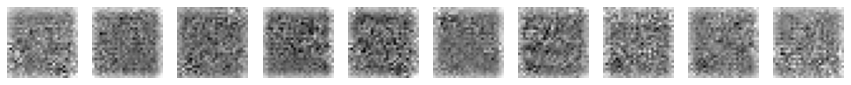

0 [D loss: 0.693853, acc.: 25.39%] [G loss: 0.692503]


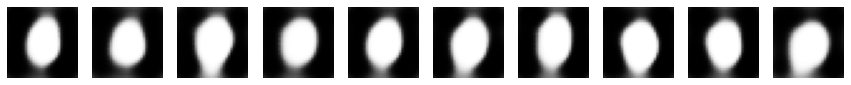

150 [D loss: 0.692473, acc.: 48.83%] [G loss: 0.680331]


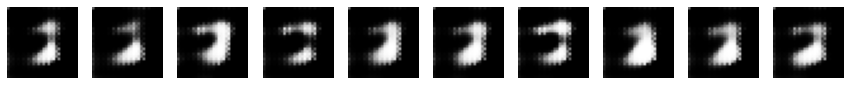

300 [D loss: 0.685998, acc.: 49.22%] [G loss: 0.662277]


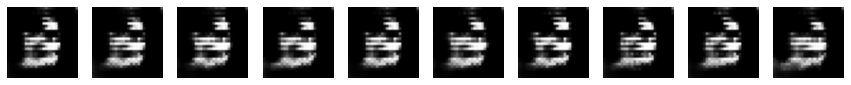

450 [D loss: 0.691815, acc.: 49.61%] [G loss: 0.729548]


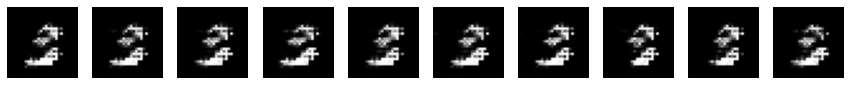

600 [D loss: 0.712502, acc.: 48.05%] [G loss: 0.705979]


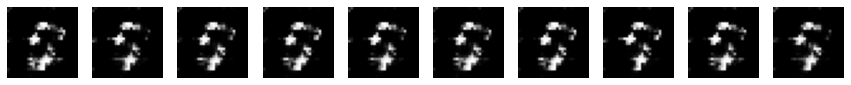

750 [D loss: 0.634760, acc.: 69.14%] [G loss: 0.810113]


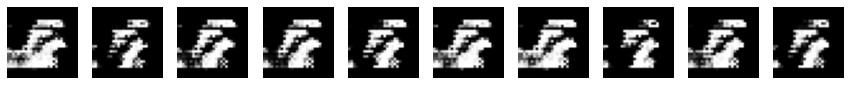

900 [D loss: 0.634682, acc.: 67.19%] [G loss: 0.835964]


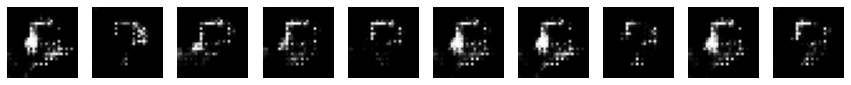

1050 [D loss: 0.532579, acc.: 82.42%] [G loss: 1.084006]


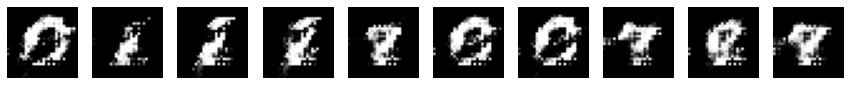

1200 [D loss: 0.617129, acc.: 74.61%] [G loss: 0.855430]


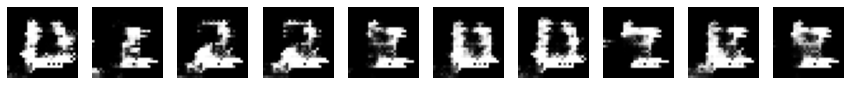

1350 [D loss: 0.556976, acc.: 73.44%] [G loss: 0.951376]


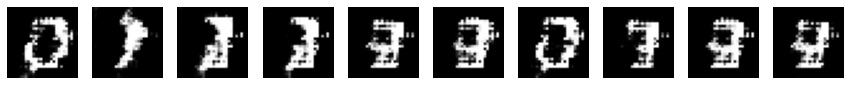

1500 [D loss: 0.518365, acc.: 75.00%] [G loss: 1.057031]


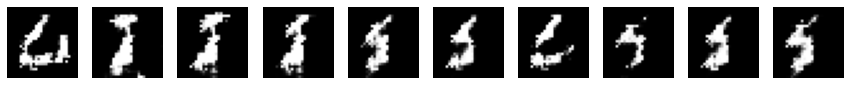

1650 [D loss: 0.661807, acc.: 57.81%] [G loss: 0.825854]


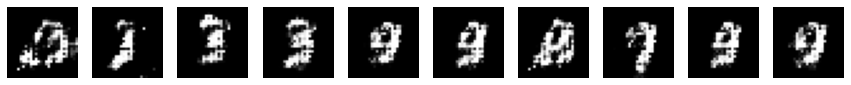

1800 [D loss: 0.595090, acc.: 72.66%] [G loss: 0.856295]


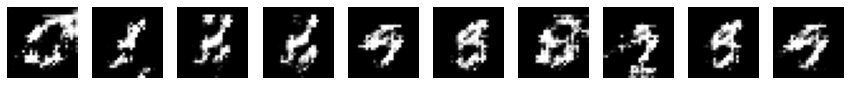

1950 [D loss: 0.671182, acc.: 60.16%] [G loss: 0.742452]


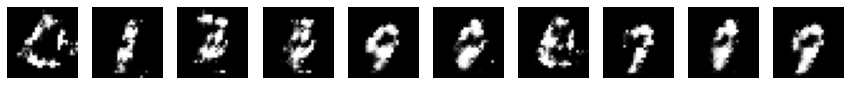

2100 [D loss: 0.642931, acc.: 64.45%] [G loss: 0.801428]


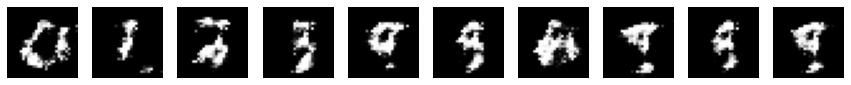

2250 [D loss: 0.610367, acc.: 70.31%] [G loss: 0.858884]


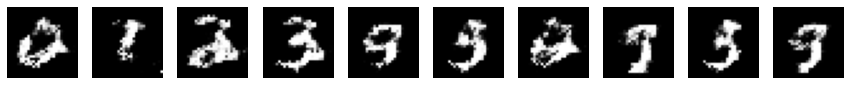

2400 [D loss: 0.659071, acc.: 60.55%] [G loss: 0.751453]


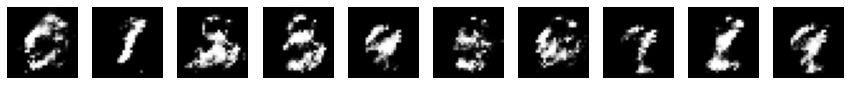

2550 [D loss: 0.640687, acc.: 65.23%] [G loss: 0.796604]


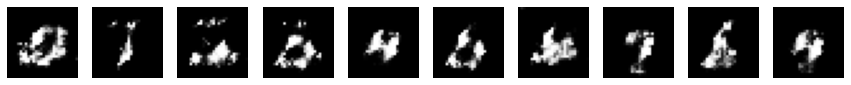

2700 [D loss: 0.647652, acc.: 68.36%] [G loss: 0.817601]


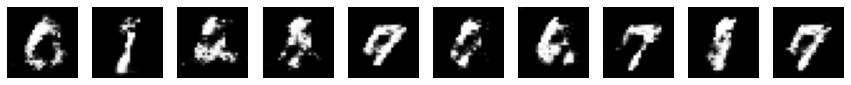

2850 [D loss: 0.666225, acc.: 63.67%] [G loss: 0.754013]


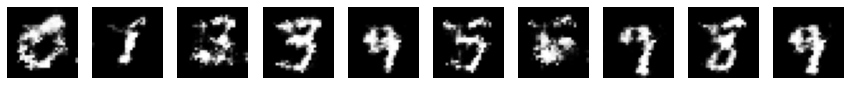

3000 [D loss: 0.668368, acc.: 59.77%] [G loss: 0.752220]


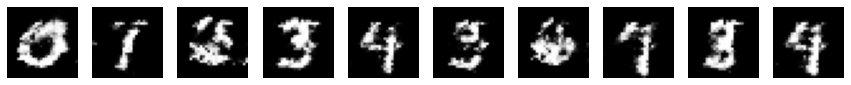

3150 [D loss: 0.681979, acc.: 56.64%] [G loss: 0.745276]


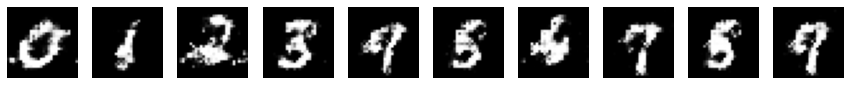

3300 [D loss: 0.668530, acc.: 61.33%] [G loss: 0.723312]


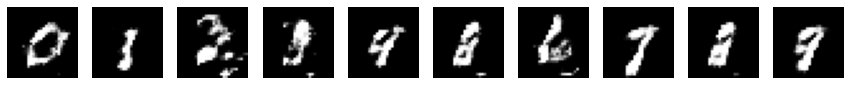

3450 [D loss: 0.682546, acc.: 53.52%] [G loss: 0.751090]


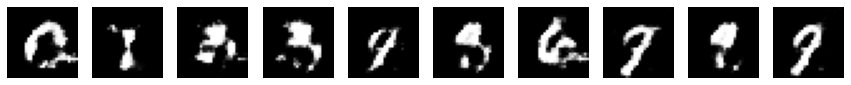

3600 [D loss: 0.687161, acc.: 54.69%] [G loss: 0.713251]


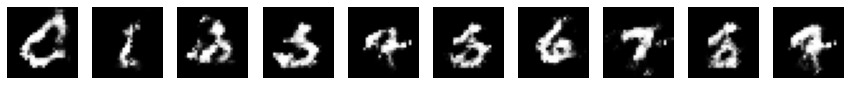

3750 [D loss: 0.686455, acc.: 53.91%] [G loss: 0.730712]


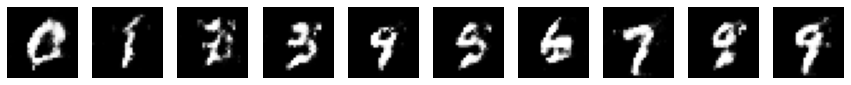

3900 [D loss: 0.682512, acc.: 56.25%] [G loss: 0.722783]


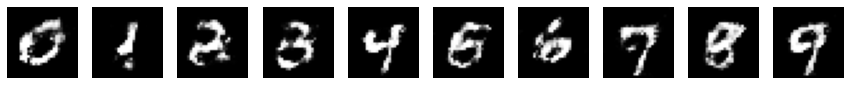

4050 [D loss: 0.674178, acc.: 60.55%] [G loss: 0.723946]


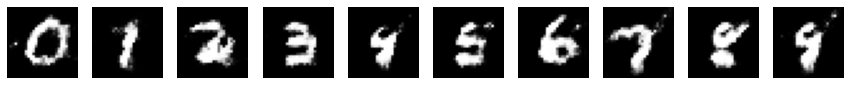

4200 [D loss: 0.681968, acc.: 57.42%] [G loss: 0.738138]


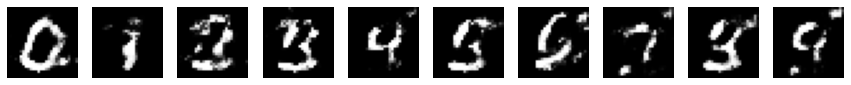

4350 [D loss: 0.689881, acc.: 51.17%] [G loss: 0.739351]


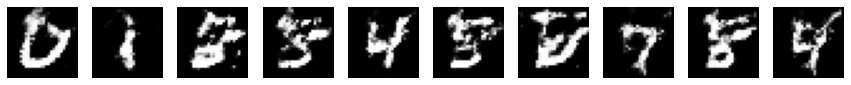

4500 [D loss: 0.682446, acc.: 52.34%] [G loss: 0.722515]


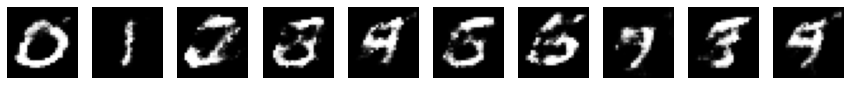

4650 [D loss: 0.682640, acc.: 56.25%] [G loss: 0.723360]


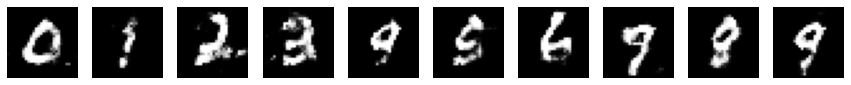

4800 [D loss: 0.692248, acc.: 54.30%] [G loss: 0.717294]


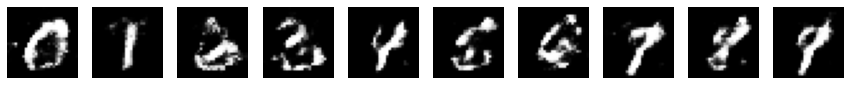

4950 [D loss: 0.681572, acc.: 59.38%] [G loss: 0.724848]


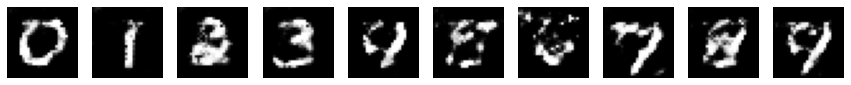

5100 [D loss: 0.683312, acc.: 57.81%] [G loss: 0.727265]


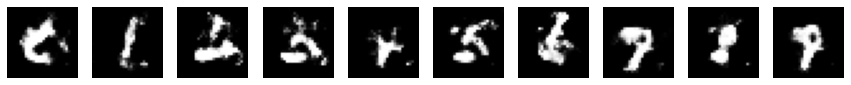

5250 [D loss: 0.682158, acc.: 54.69%] [G loss: 0.735161]


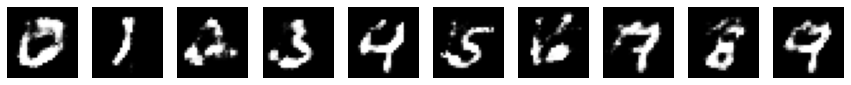

5400 [D loss: 0.659226, acc.: 60.55%] [G loss: 0.731055]


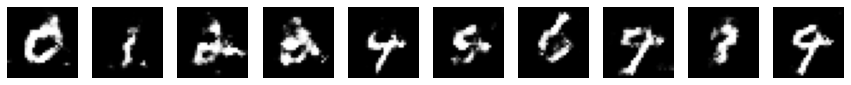

5550 [D loss: 0.686386, acc.: 51.56%] [G loss: 0.746019]


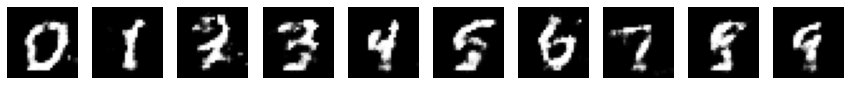

5700 [D loss: 0.691324, acc.: 55.86%] [G loss: 0.711417]


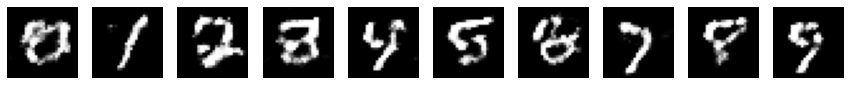

5850 [D loss: 0.686612, acc.: 51.95%] [G loss: 0.725160]


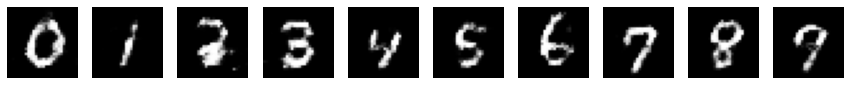

6000 [D loss: 0.687282, acc.: 52.34%] [G loss: 0.717077]


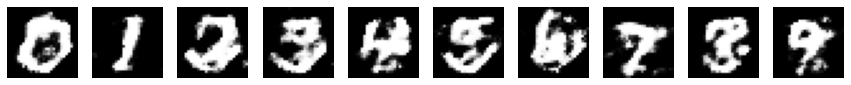

6150 [D loss: 0.690869, acc.: 53.91%] [G loss: 0.728515]


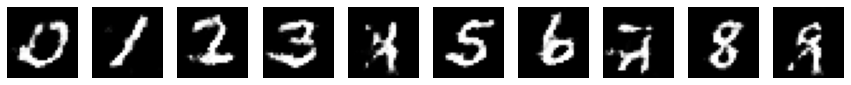

6300 [D loss: 0.684002, acc.: 57.03%] [G loss: 0.716735]


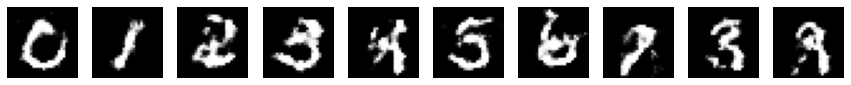

6450 [D loss: 0.674457, acc.: 62.89%] [G loss: 0.724164]


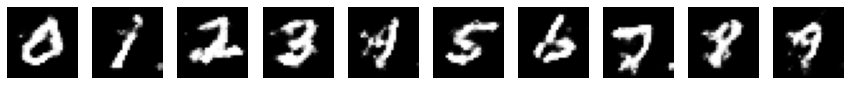

6600 [D loss: 0.680568, acc.: 55.47%] [G loss: 0.729368]


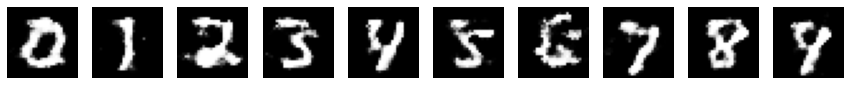

6750 [D loss: 0.689470, acc.: 52.73%] [G loss: 0.727044]


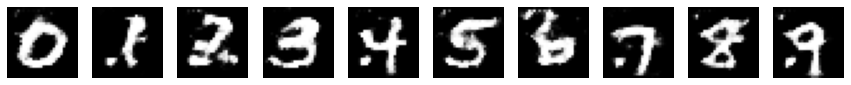

6900 [D loss: 0.694977, acc.: 51.95%] [G loss: 0.720796]


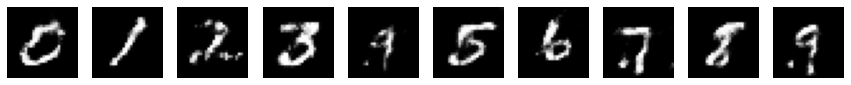

7050 [D loss: 0.679357, acc.: 55.47%] [G loss: 0.725094]


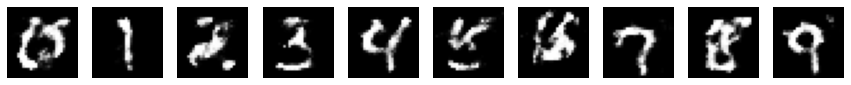

7200 [D loss: 0.676786, acc.: 57.81%] [G loss: 0.727668]


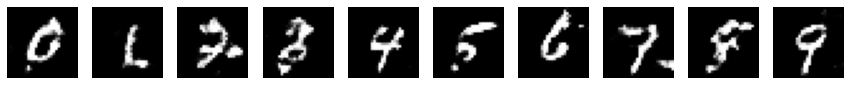

7350 [D loss: 0.672287, acc.: 59.38%] [G loss: 0.719126]


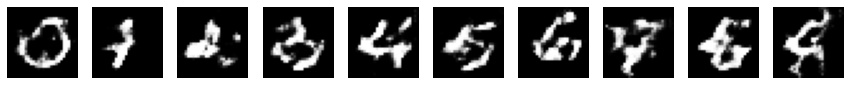

7500 [D loss: 0.683802, acc.: 59.38%] [G loss: 0.732567]


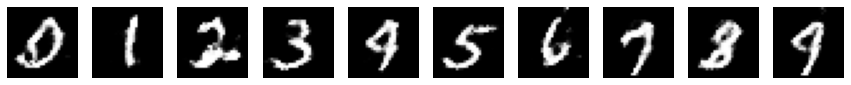

7650 [D loss: 0.680346, acc.: 56.25%] [G loss: 0.740522]


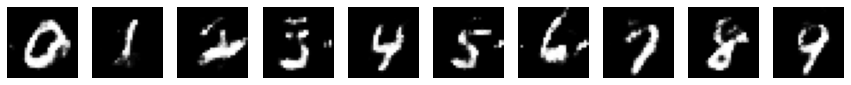

7800 [D loss: 0.681434, acc.: 57.42%] [G loss: 0.741422]


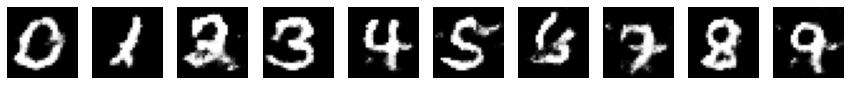

7950 [D loss: 0.690551, acc.: 51.56%] [G loss: 0.720387]


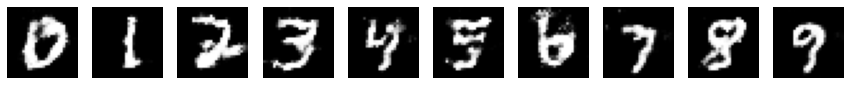

8100 [D loss: 0.683117, acc.: 56.64%] [G loss: 0.738888]


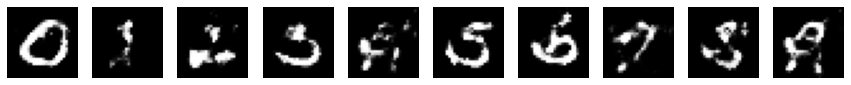

8250 [D loss: 0.679631, acc.: 57.81%] [G loss: 0.746029]


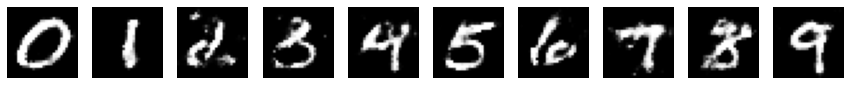

8400 [D loss: 0.680610, acc.: 53.12%] [G loss: 0.739575]


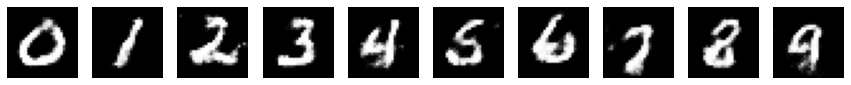

8550 [D loss: 0.676886, acc.: 57.42%] [G loss: 0.724496]


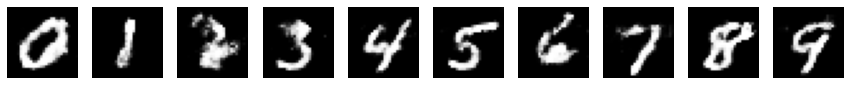

8700 [D loss: 0.678722, acc.: 57.42%] [G loss: 0.726012]


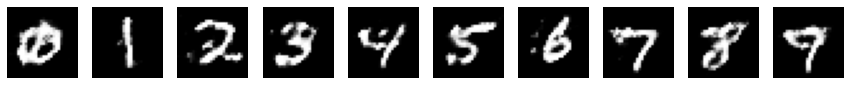

8850 [D loss: 0.682636, acc.: 54.69%] [G loss: 0.734839]


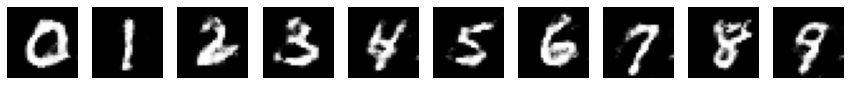

9000 [D loss: 0.689090, acc.: 53.91%] [G loss: 0.723008]


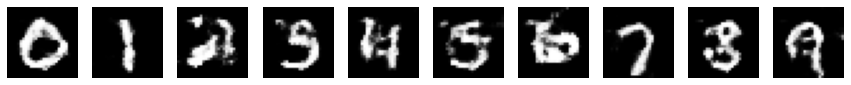

9150 [D loss: 0.669743, acc.: 57.81%] [G loss: 0.729535]


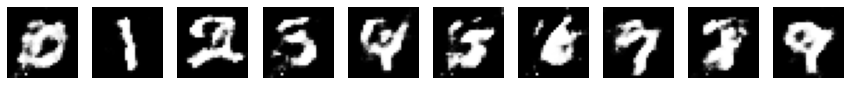

9300 [D loss: 0.611142, acc.: 76.17%] [G loss: 0.896933]


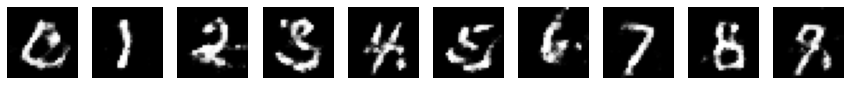

9450 [D loss: 0.686767, acc.: 54.30%] [G loss: 0.723229]


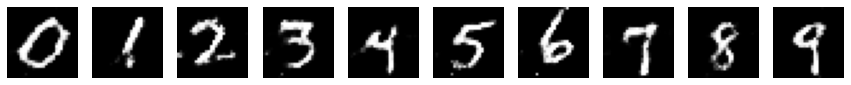

9600 [D loss: 0.669959, acc.: 60.94%] [G loss: 0.747601]


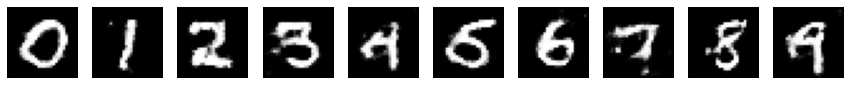

9750 [D loss: 0.683468, acc.: 57.42%] [G loss: 0.727515]


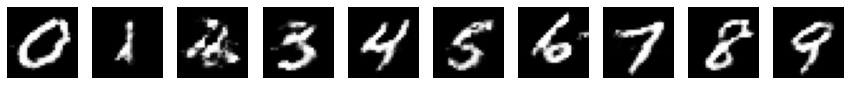

9900 [D loss: 0.693321, acc.: 54.30%] [G loss: 0.729012]


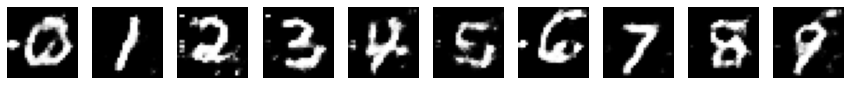

10050 [D loss: 0.683805, acc.: 57.81%] [G loss: 0.732262]


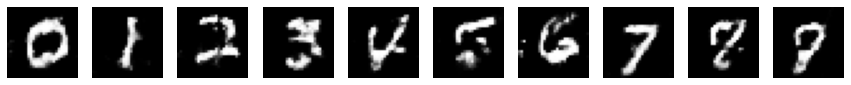

10200 [D loss: 0.679758, acc.: 57.42%] [G loss: 0.730359]


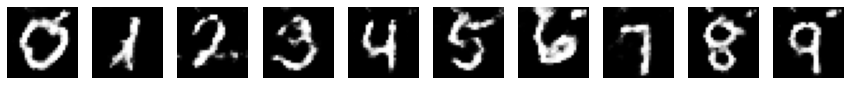

10350 [D loss: 0.686427, acc.: 56.64%] [G loss: 0.743273]


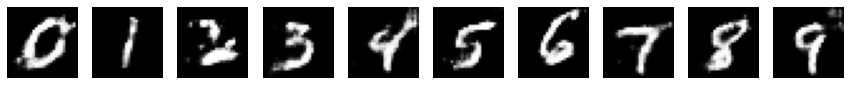

10500 [D loss: 0.669570, acc.: 57.03%] [G loss: 0.726681]


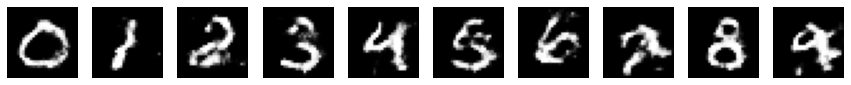

10650 [D loss: 0.684689, acc.: 57.81%] [G loss: 0.736996]


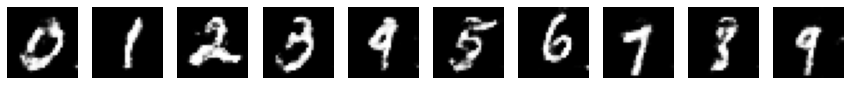

10800 [D loss: 0.678777, acc.: 54.30%] [G loss: 0.701227]


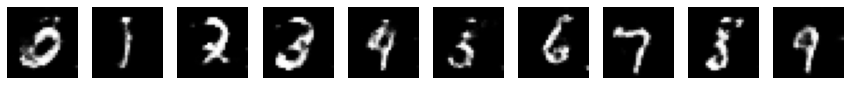

10950 [D loss: 0.677712, acc.: 58.59%] [G loss: 0.736568]


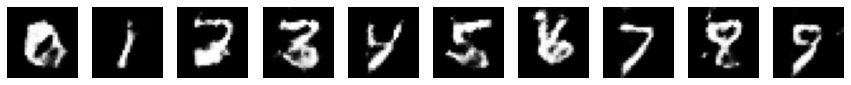

11100 [D loss: 0.692204, acc.: 54.30%] [G loss: 0.734937]


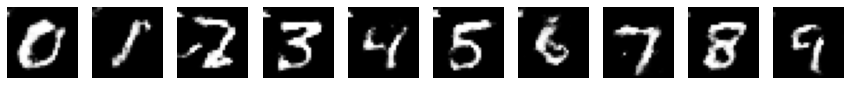

11250 [D loss: 0.679871, acc.: 56.64%] [G loss: 0.728214]


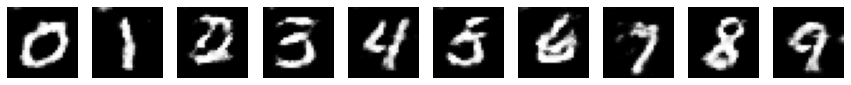

11400 [D loss: 0.690112, acc.: 51.95%] [G loss: 0.726940]


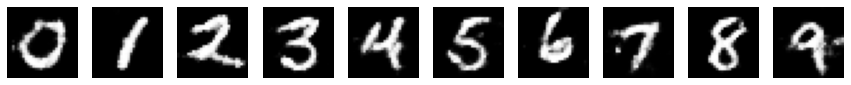

11550 [D loss: 0.676800, acc.: 57.03%] [G loss: 0.741518]


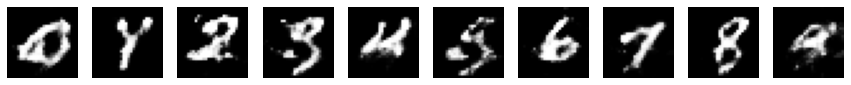

11700 [D loss: 0.693567, acc.: 54.30%] [G loss: 0.739539]


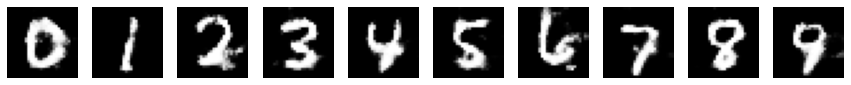

11850 [D loss: 0.673720, acc.: 62.89%] [G loss: 0.758204]


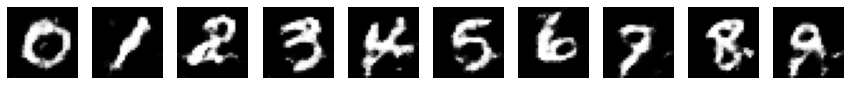

12000 [D loss: 0.685351, acc.: 54.30%] [G loss: 0.708076]


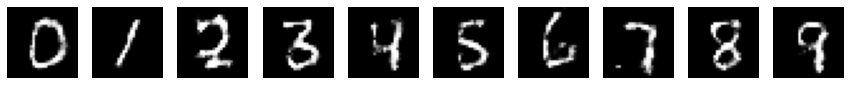

12150 [D loss: 0.656594, acc.: 62.50%] [G loss: 0.758479]


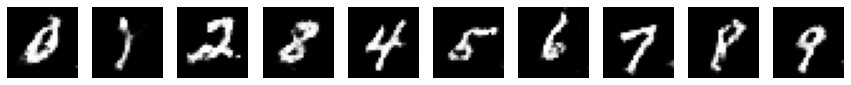

12300 [D loss: 0.692150, acc.: 50.39%] [G loss: 0.735532]


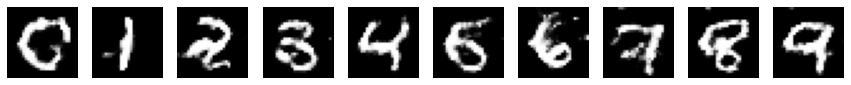

12450 [D loss: 0.686257, acc.: 57.03%] [G loss: 0.748126]


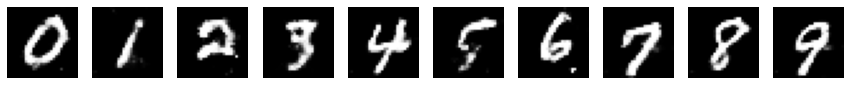

12600 [D loss: 0.690786, acc.: 53.91%] [G loss: 0.709326]


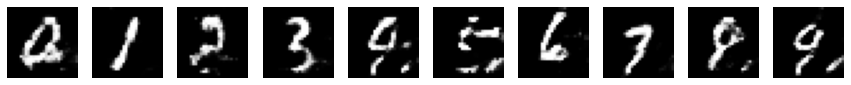

12750 [D loss: 0.693681, acc.: 54.69%] [G loss: 0.707002]


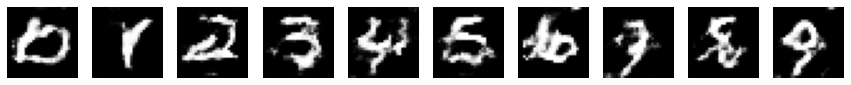

12900 [D loss: 0.675394, acc.: 59.77%] [G loss: 0.720033]


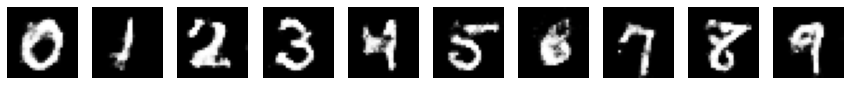

13050 [D loss: 0.676399, acc.: 56.25%] [G loss: 0.731324]


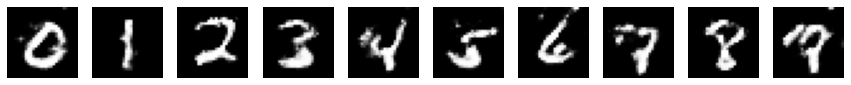

13200 [D loss: 0.695001, acc.: 50.39%] [G loss: 0.735081]


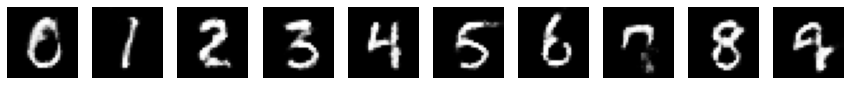

13350 [D loss: 0.677899, acc.: 57.42%] [G loss: 0.726701]


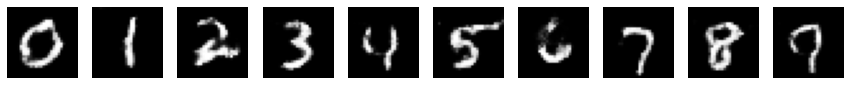

13500 [D loss: 0.687928, acc.: 54.69%] [G loss: 0.726719]


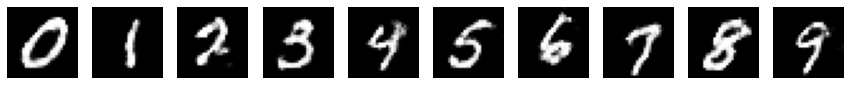

13650 [D loss: 0.686936, acc.: 54.30%] [G loss: 0.718185]


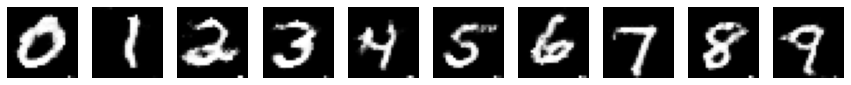

13800 [D loss: 0.691067, acc.: 53.52%] [G loss: 0.727706]


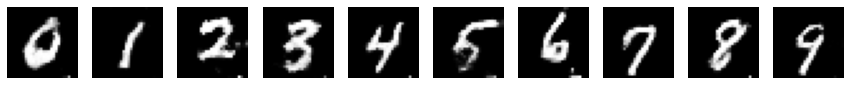

13950 [D loss: 0.679599, acc.: 56.25%] [G loss: 0.728353]


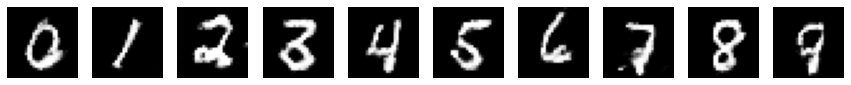

14100 [D loss: 0.686033, acc.: 53.52%] [G loss: 0.741877]


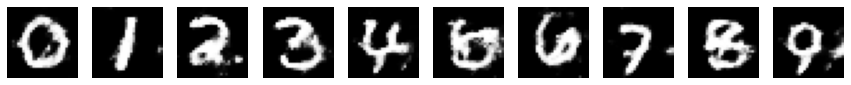

14250 [D loss: 0.697191, acc.: 53.52%] [G loss: 0.715320]


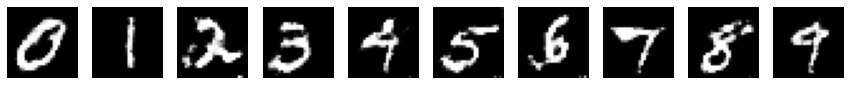

14400 [D loss: 0.688483, acc.: 54.69%] [G loss: 0.714220]


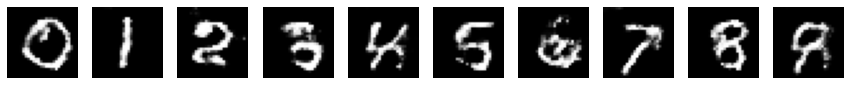

14550 [D loss: 0.685614, acc.: 55.86%] [G loss: 0.716660]


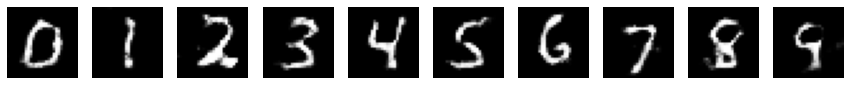

14700 [D loss: 0.675011, acc.: 55.86%] [G loss: 0.735851]


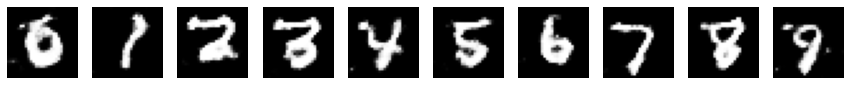

14850 [D loss: 0.684011, acc.: 55.47%] [G loss: 0.708395]


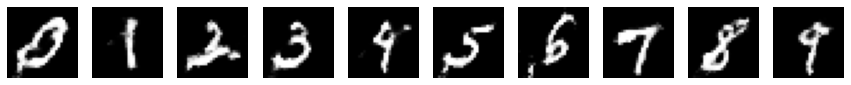

15000 [D loss: 0.679804, acc.: 54.69%] [G loss: 0.724979]


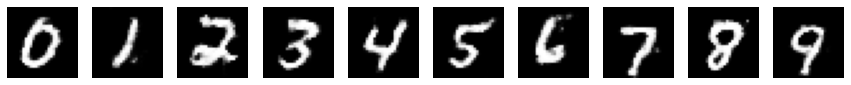

15150 [D loss: 0.684752, acc.: 55.47%] [G loss: 0.716640]


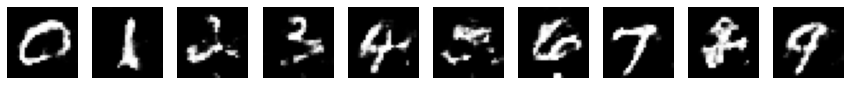

15300 [D loss: 0.697201, acc.: 50.78%] [G loss: 0.737181]


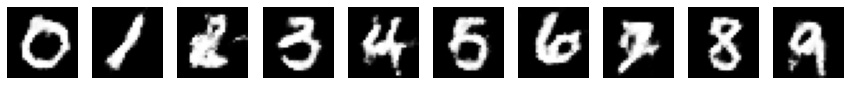

15450 [D loss: 0.677650, acc.: 56.64%] [G loss: 0.744442]


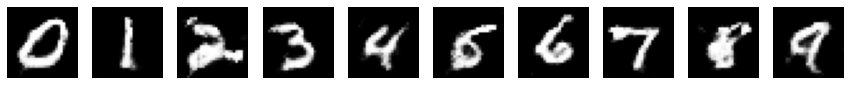

15600 [D loss: 0.686314, acc.: 51.56%] [G loss: 0.730037]


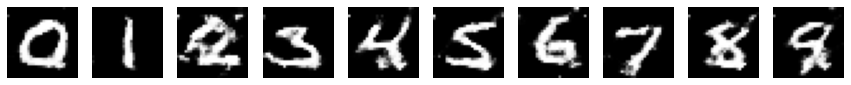

15750 [D loss: 0.685432, acc.: 52.73%] [G loss: 0.735780]


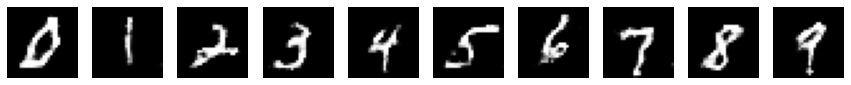

15900 [D loss: 0.688559, acc.: 52.34%] [G loss: 0.725770]


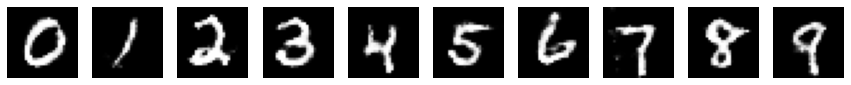

16050 [D loss: 0.703194, acc.: 49.22%] [G loss: 0.705126]


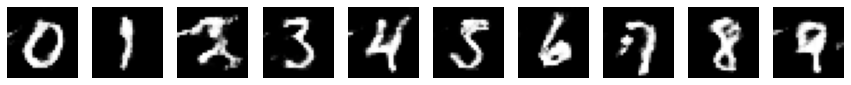

16200 [D loss: 0.682884, acc.: 55.86%] [G loss: 0.728053]


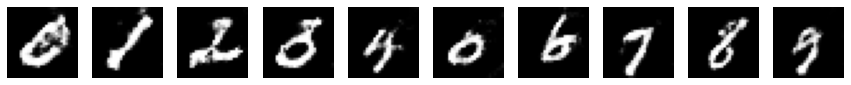

16350 [D loss: 0.686646, acc.: 51.56%] [G loss: 0.730027]


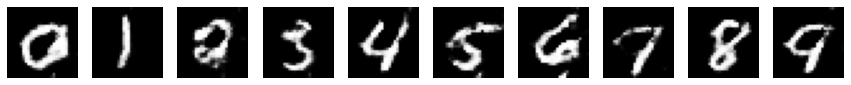

16500 [D loss: 0.688384, acc.: 56.64%] [G loss: 0.720285]


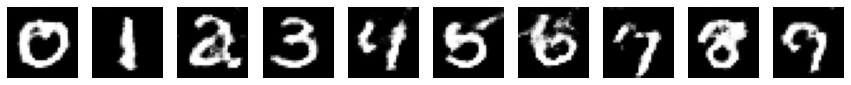

16650 [D loss: 0.689671, acc.: 52.73%] [G loss: 0.722759]


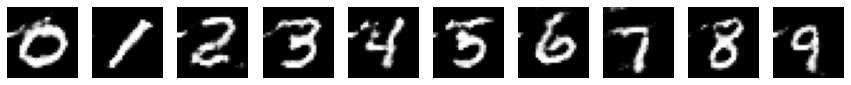

16800 [D loss: 0.677219, acc.: 58.20%] [G loss: 0.733874]


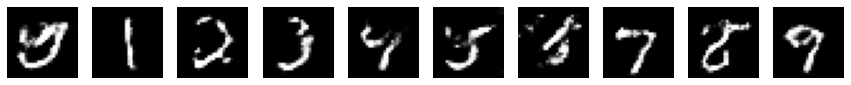

16950 [D loss: 0.682053, acc.: 54.69%] [G loss: 0.714532]


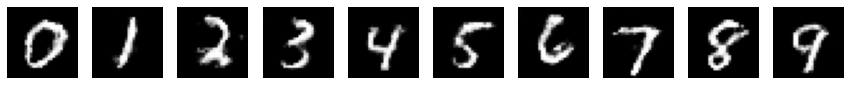

17100 [D loss: 0.678729, acc.: 58.98%] [G loss: 0.735889]


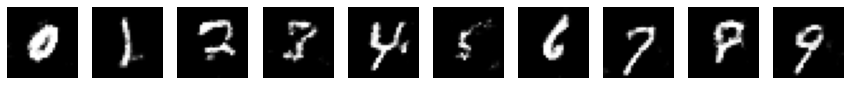

17250 [D loss: 0.678846, acc.: 54.69%] [G loss: 0.714879]


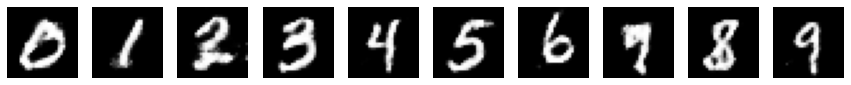

17400 [D loss: 0.679249, acc.: 58.20%] [G loss: 0.714228]


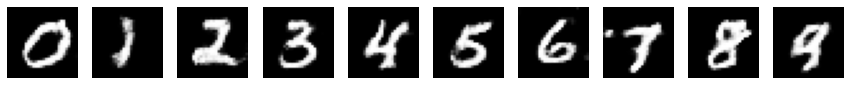

17550 [D loss: 0.679720, acc.: 55.86%] [G loss: 0.755677]


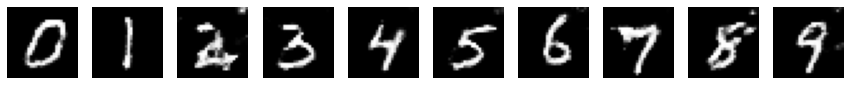

17700 [D loss: 0.694045, acc.: 52.73%] [G loss: 0.720497]


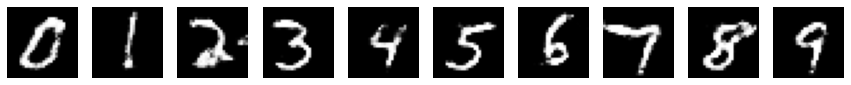

17850 [D loss: 0.679979, acc.: 57.81%] [G loss: 0.733596]


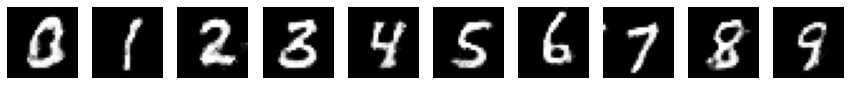

18000 [D loss: 0.681269, acc.: 57.81%] [G loss: 0.710488]


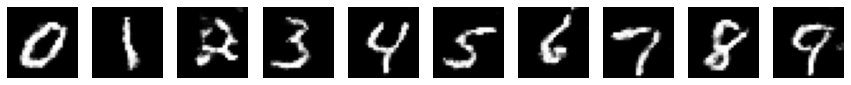

18150 [D loss: 0.689988, acc.: 57.03%] [G loss: 0.715894]


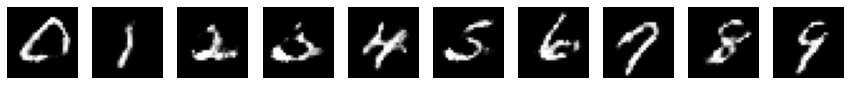

18300 [D loss: 0.686964, acc.: 54.30%] [G loss: 0.741457]


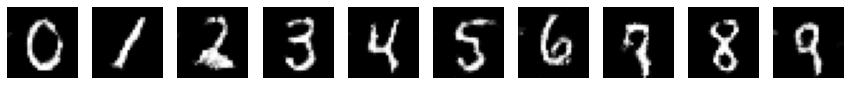

18450 [D loss: 0.693957, acc.: 48.83%] [G loss: 0.727134]


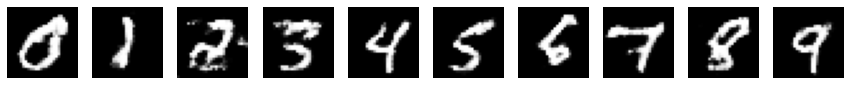

18600 [D loss: 0.685497, acc.: 53.91%] [G loss: 0.732833]


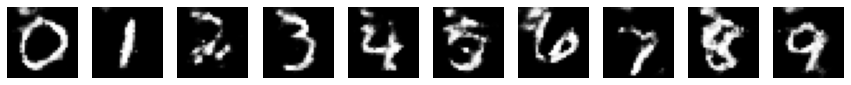

18750 [D loss: 0.684733, acc.: 56.25%] [G loss: 0.705294]


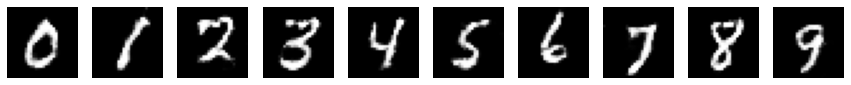

18900 [D loss: 0.701704, acc.: 46.09%] [G loss: 0.716974]


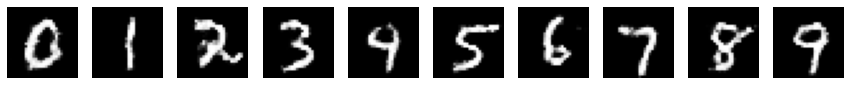

19050 [D loss: 0.680119, acc.: 60.94%] [G loss: 0.729058]


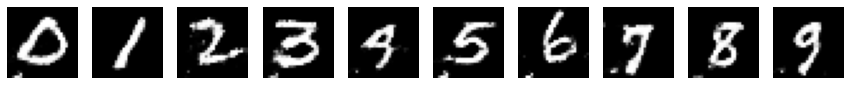

19200 [D loss: 0.686964, acc.: 53.52%] [G loss: 0.703665]


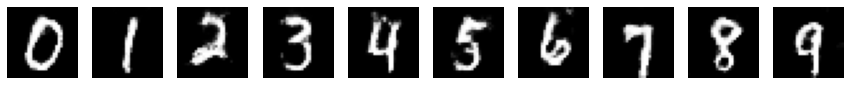

19350 [D loss: 0.690816, acc.: 56.64%] [G loss: 0.732652]


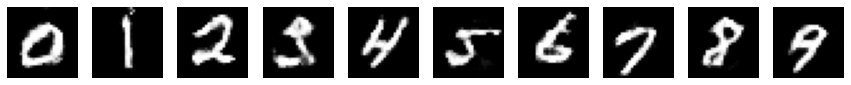

19500 [D loss: 0.682395, acc.: 53.12%] [G loss: 0.726738]


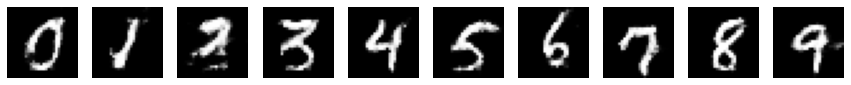

19650 [D loss: 0.693255, acc.: 52.34%] [G loss: 0.723787]


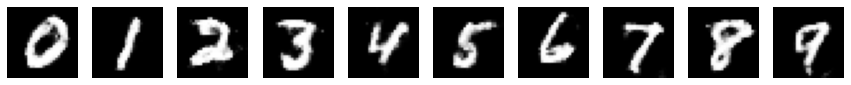

19800 [D loss: 0.688686, acc.: 56.25%] [G loss: 0.715319]


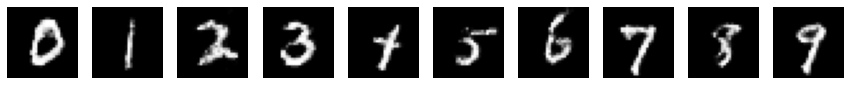

19950 [D loss: 0.685715, acc.: 55.47%] [G loss: 0.748124]


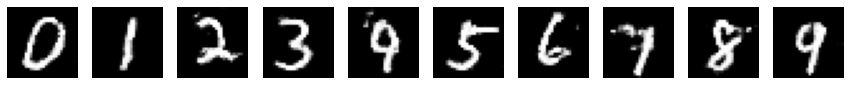

20100 [D loss: 0.686795, acc.: 53.12%] [G loss: 0.756825]


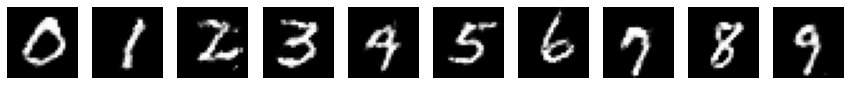

20250 [D loss: 0.683393, acc.: 54.30%] [G loss: 0.725870]


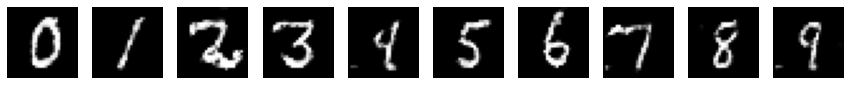

20400 [D loss: 0.684105, acc.: 57.42%] [G loss: 0.715125]


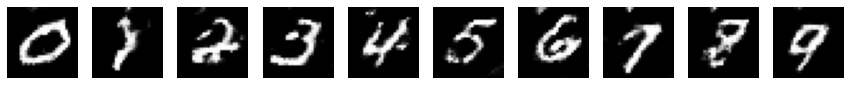

20550 [D loss: 0.684117, acc.: 53.91%] [G loss: 0.732230]


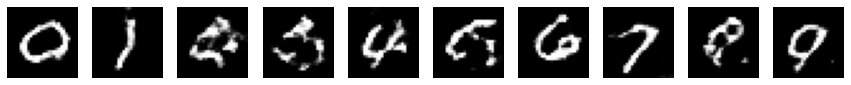

20700 [D loss: 0.704083, acc.: 48.83%] [G loss: 0.715584]


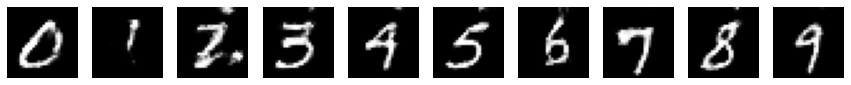

20850 [D loss: 0.683355, acc.: 57.81%] [G loss: 0.717379]


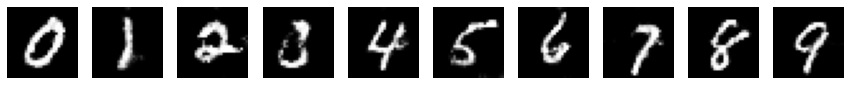

21000 [D loss: 0.685627, acc.: 54.69%] [G loss: 0.712365]


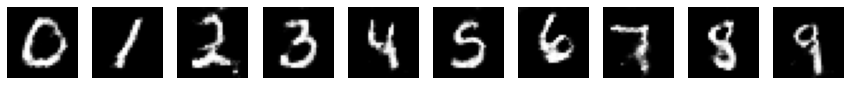

21150 [D loss: 0.690844, acc.: 54.30%] [G loss: 0.734525]


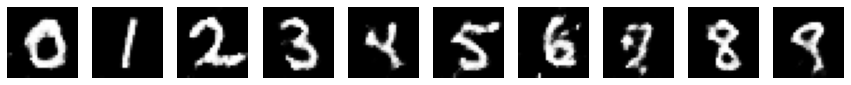

21300 [D loss: 0.680779, acc.: 53.91%] [G loss: 0.735993]


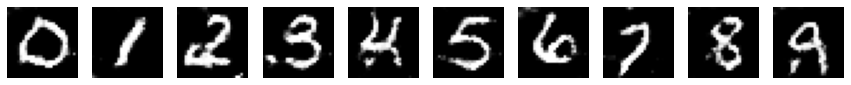

21450 [D loss: 0.680633, acc.: 55.86%] [G loss: 0.705577]


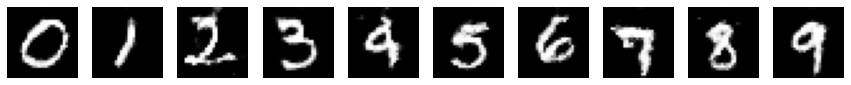

21600 [D loss: 0.682398, acc.: 56.64%] [G loss: 0.720208]


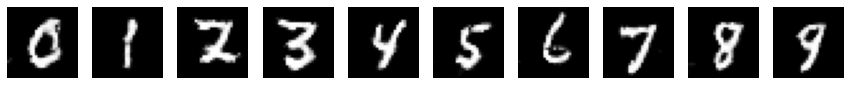

21750 [D loss: 0.691411, acc.: 51.95%] [G loss: 0.729866]


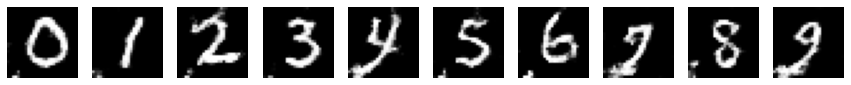

21900 [D loss: 0.684919, acc.: 53.12%] [G loss: 0.723621]


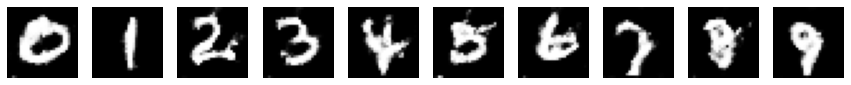

22050 [D loss: 0.674742, acc.: 59.77%] [G loss: 0.734802]


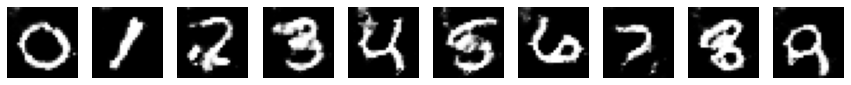

22200 [D loss: 0.673985, acc.: 57.42%] [G loss: 0.715058]


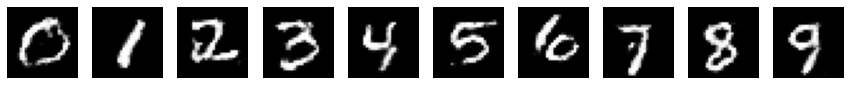

22350 [D loss: 0.678003, acc.: 57.42%] [G loss: 0.731688]


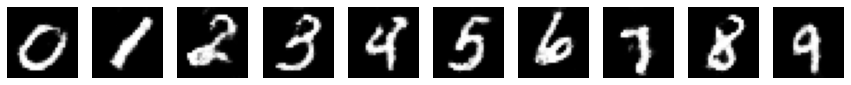

22500 [D loss: 0.668373, acc.: 61.33%] [G loss: 0.715239]


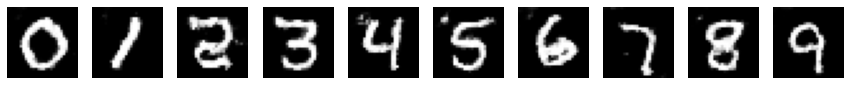

22650 [D loss: 0.688439, acc.: 54.69%] [G loss: 0.721154]


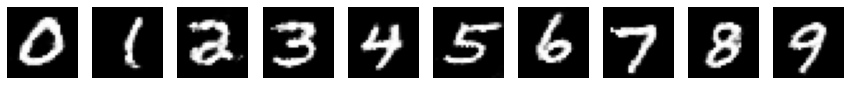

22800 [D loss: 0.682926, acc.: 55.86%] [G loss: 0.725836]


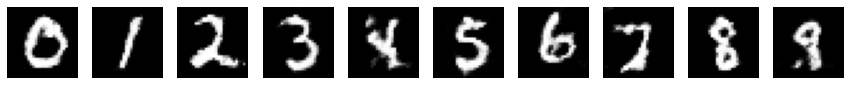

22950 [D loss: 0.682782, acc.: 54.30%] [G loss: 0.727580]


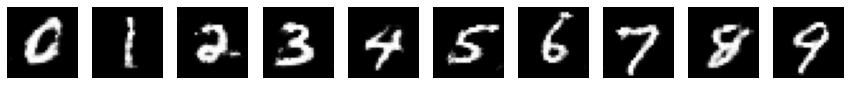

23100 [D loss: 0.682237, acc.: 57.03%] [G loss: 0.717904]


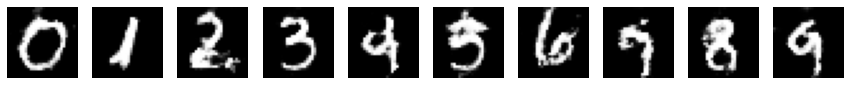

23250 [D loss: 0.691879, acc.: 52.73%] [G loss: 0.727362]


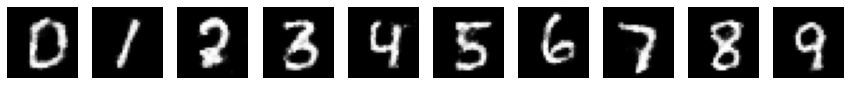

23400 [D loss: 0.689333, acc.: 52.73%] [G loss: 0.725640]


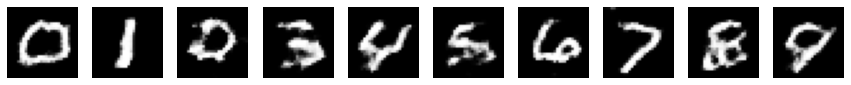

23550 [D loss: 0.658434, acc.: 62.50%] [G loss: 0.741539]


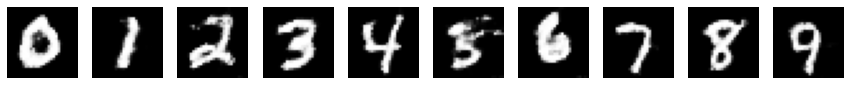

23700 [D loss: 0.679302, acc.: 54.30%] [G loss: 0.735901]


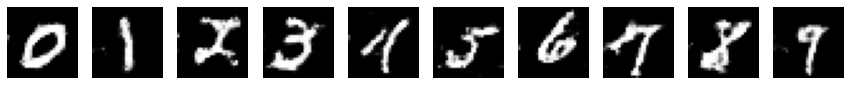

23850 [D loss: 0.693523, acc.: 53.12%] [G loss: 0.721519]


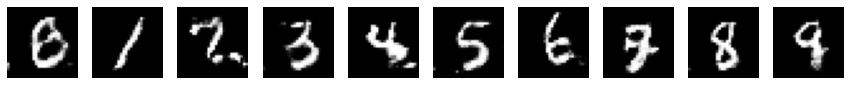

24000 [D loss: 0.697154, acc.: 52.73%] [G loss: 0.719013]


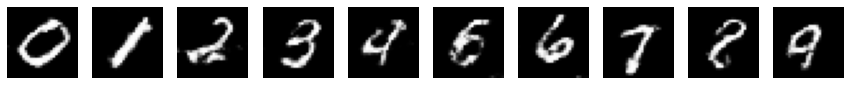

24150 [D loss: 0.686838, acc.: 54.30%] [G loss: 0.701755]


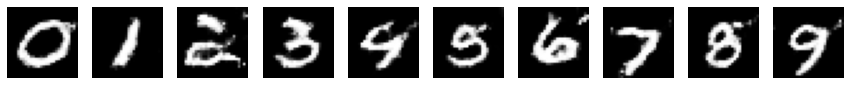

24300 [D loss: 0.680294, acc.: 57.81%] [G loss: 0.723088]


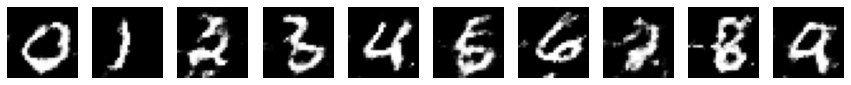

24450 [D loss: 0.688893, acc.: 51.17%] [G loss: 0.718652]


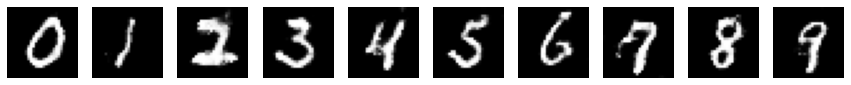

24600 [D loss: 0.691793, acc.: 52.73%] [G loss: 0.726221]


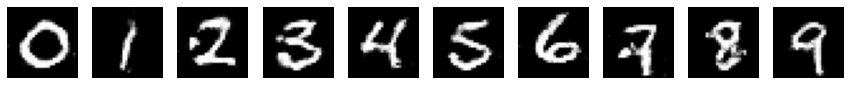

24750 [D loss: 0.681431, acc.: 56.25%] [G loss: 0.724932]


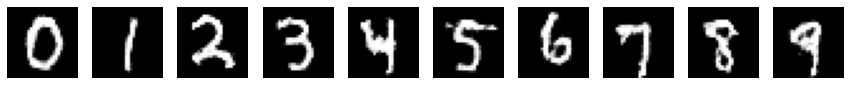

24900 [D loss: 0.696841, acc.: 48.44%] [G loss: 0.723439]


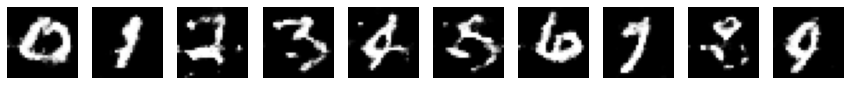

25050 [D loss: 0.685896, acc.: 55.08%] [G loss: 0.723790]


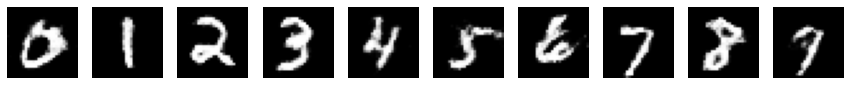

25200 [D loss: 0.688633, acc.: 52.34%] [G loss: 0.712645]


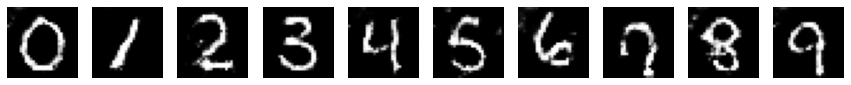

25350 [D loss: 0.684612, acc.: 52.34%] [G loss: 0.708548]


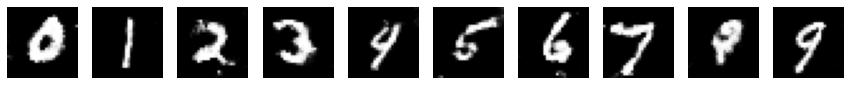

25500 [D loss: 0.685014, acc.: 56.64%] [G loss: 0.734789]


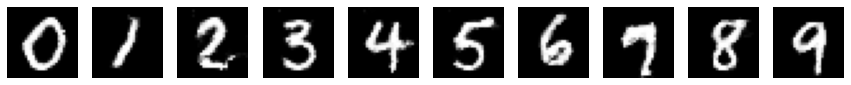

25650 [D loss: 0.696347, acc.: 50.39%] [G loss: 0.741490]


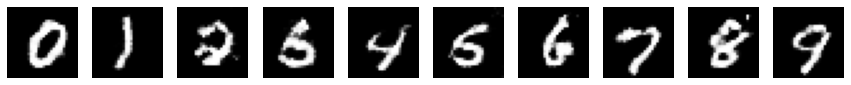

25800 [D loss: 0.681084, acc.: 58.59%] [G loss: 0.716200]


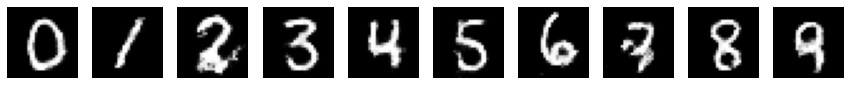

25950 [D loss: 0.684678, acc.: 53.12%] [G loss: 0.741244]


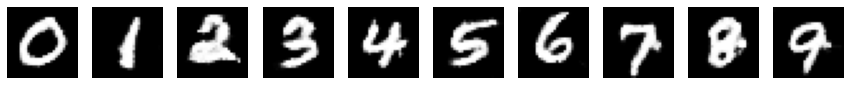

26100 [D loss: 0.701041, acc.: 50.78%] [G loss: 0.723541]


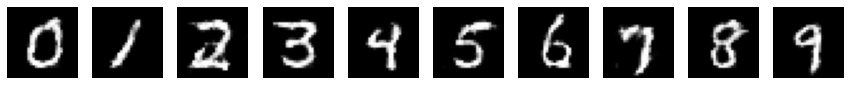

26250 [D loss: 0.681917, acc.: 58.20%] [G loss: 0.742094]


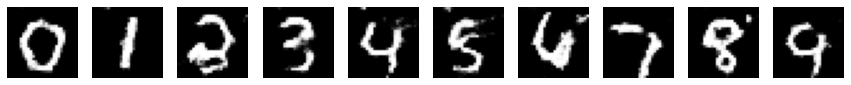

26400 [D loss: 0.680061, acc.: 55.47%] [G loss: 0.724235]


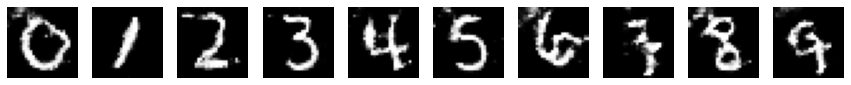

26550 [D loss: 0.680787, acc.: 54.69%] [G loss: 0.724341]


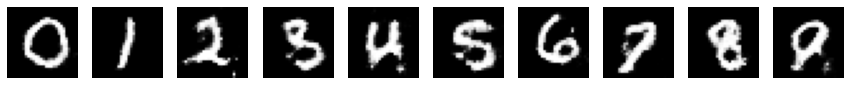

26700 [D loss: 0.678838, acc.: 55.08%] [G loss: 0.769705]


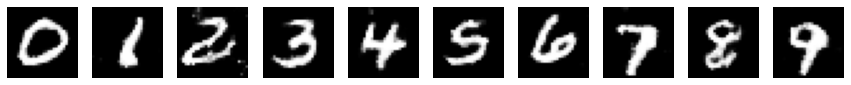

26850 [D loss: 0.688915, acc.: 56.25%] [G loss: 0.719520]


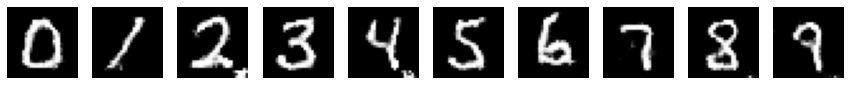

27000 [D loss: 0.678716, acc.: 57.03%] [G loss: 0.717199]


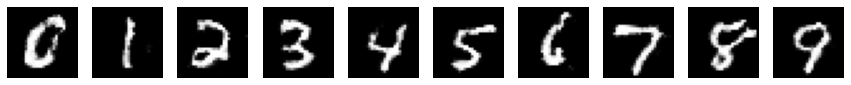

27150 [D loss: 0.678632, acc.: 57.03%] [G loss: 0.734900]


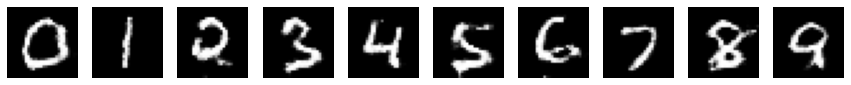

27300 [D loss: 0.693478, acc.: 53.91%] [G loss: 0.754507]


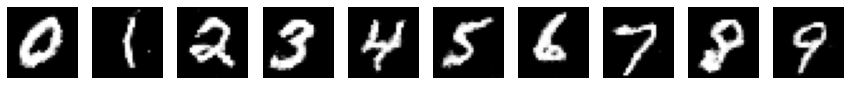

27450 [D loss: 0.679440, acc.: 57.42%] [G loss: 0.732380]


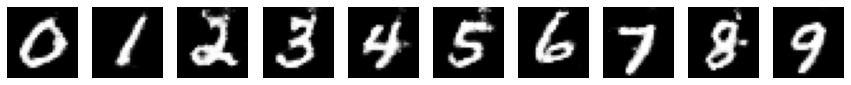

27600 [D loss: 0.682243, acc.: 53.52%] [G loss: 0.714158]


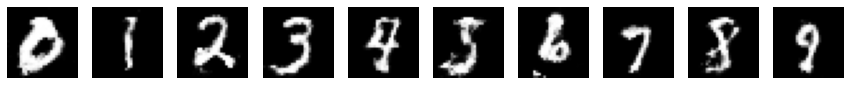

27750 [D loss: 0.678046, acc.: 60.94%] [G loss: 0.723163]


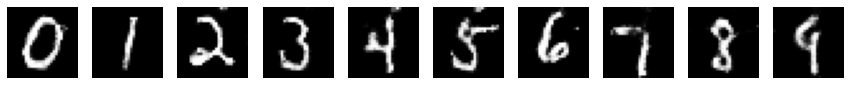

27900 [D loss: 0.678389, acc.: 56.64%] [G loss: 0.717369]


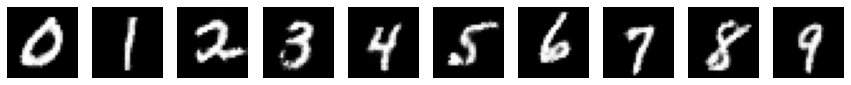

28050 [D loss: 0.683666, acc.: 55.86%] [G loss: 0.750376]


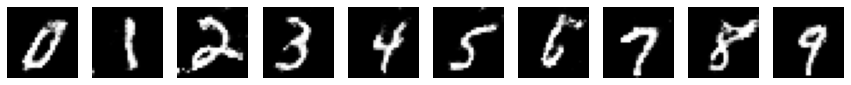

28200 [D loss: 0.689378, acc.: 54.69%] [G loss: 0.733133]


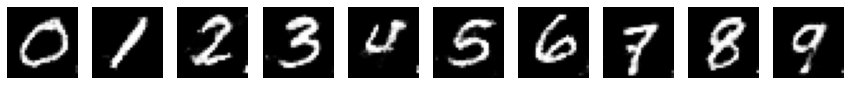

28350 [D loss: 0.697706, acc.: 51.56%] [G loss: 0.742324]


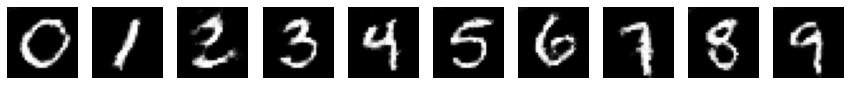

28500 [D loss: 0.687099, acc.: 57.03%] [G loss: 0.727085]


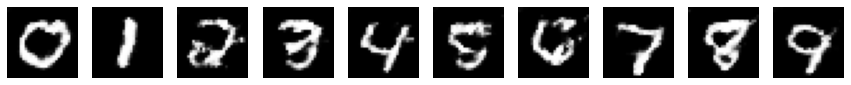

28650 [D loss: 0.697664, acc.: 53.91%] [G loss: 0.691182]


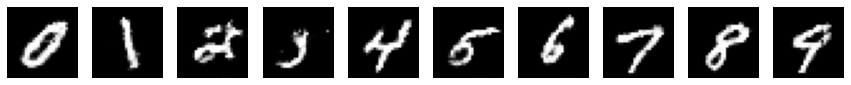

28800 [D loss: 0.685187, acc.: 55.47%] [G loss: 0.728652]


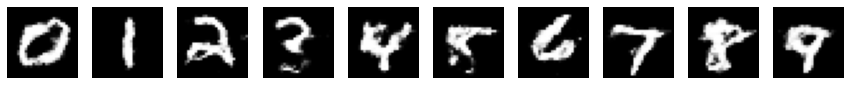

28950 [D loss: 0.688562, acc.: 55.47%] [G loss: 0.707427]


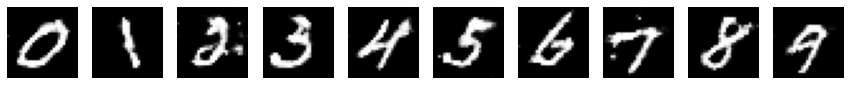

29100 [D loss: 0.670858, acc.: 59.38%] [G loss: 0.759749]


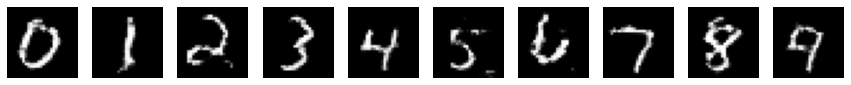

29250 [D loss: 0.687109, acc.: 54.69%] [G loss: 0.735848]


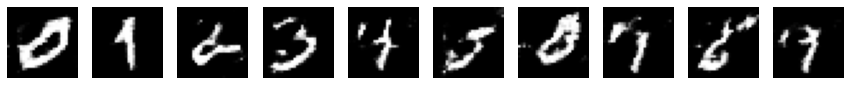

29400 [D loss: 0.687950, acc.: 53.91%] [G loss: 0.733476]


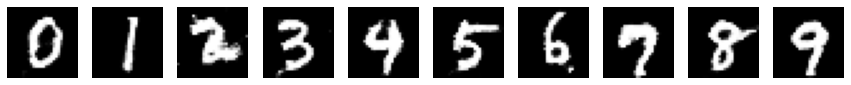

29550 [D loss: 0.696677, acc.: 51.17%] [G loss: 0.713938]


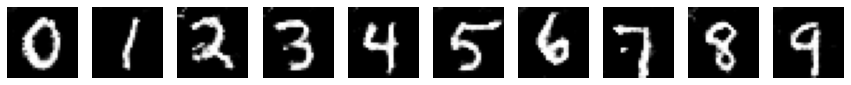

29700 [D loss: 0.688610, acc.: 52.73%] [G loss: 0.723875]


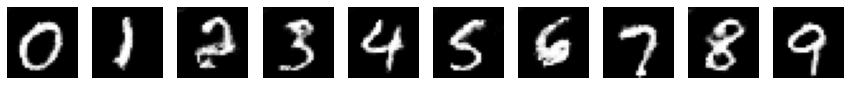

29850 [D loss: 0.673079, acc.: 60.55%] [G loss: 0.725439]


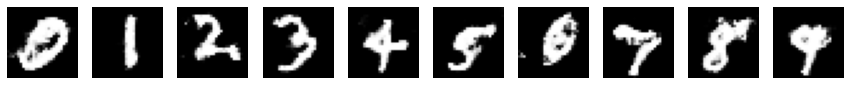

29999 [D loss: 0.698594, acc.: 51.56%] [G loss: 0.736152]


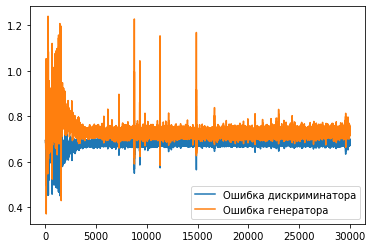

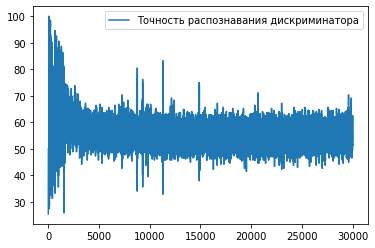

In [ ]:
CGAN_algoritm(cc_gen, cc_discriminator, 30000)

### Демонстрация результата

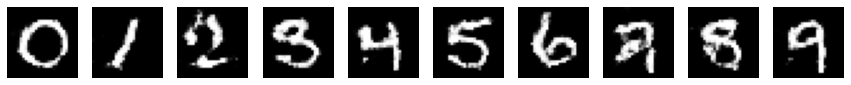

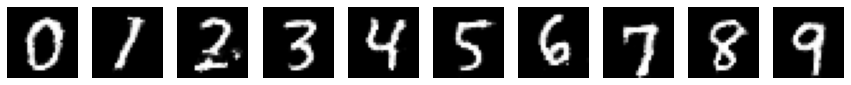

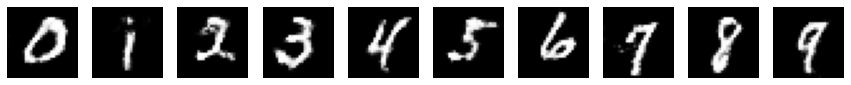

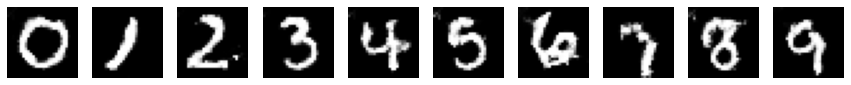

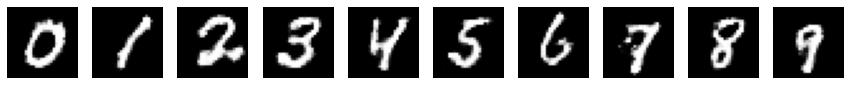

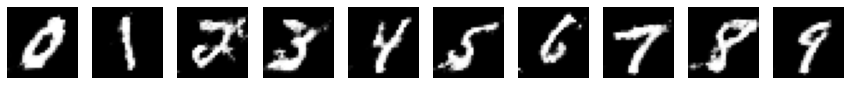

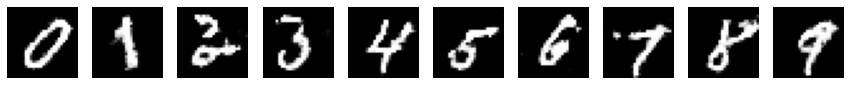

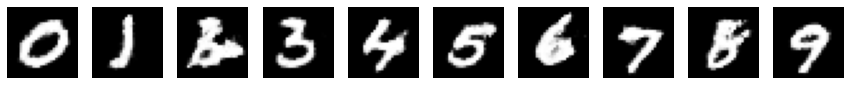

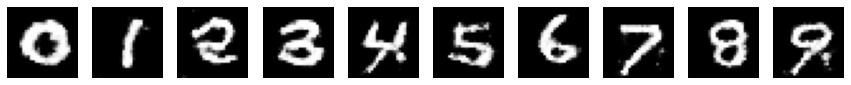

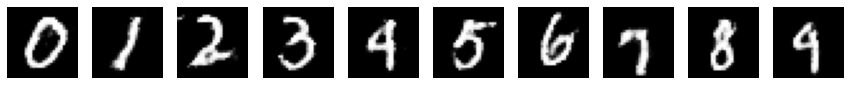

In [ ]:
# Вектор со случайным распределением

for n in range(10):
  noise = np.random.normal(size=(1,random_vec))
  sampled_labels = np.arange(0, 10).reshape(-1, 1) # Создаем массив меток от 0 до 10 и решейпим его в размерность (10, 1)
  fig = plt.figure(figsize=(15, 20)) # Задаем размер фигуры

  for i in range (10): # Перебираем по очереди все лейблы
    plt.subplot(1, 10, i+1)
    predict_gen = cc_gen.predict([noise,sampled_labels[i]], verbose = 0) #генерируем изображение из шума по заданному лейблу
    plt.imshow(predict_gen[0].reshape(28, 28), cmap='gray') # Выводим картинку на полотно
    plt.axis('off') # Отключаем оси

  plt.show() # Выводим все полотно на экран

Как видим, на рисунке выше, сгенерированы новые цифры, которых ранее никогда не существовало.

# Заключение

Краткие рекомендации для устойчивого обучения глубоких сверточных генеративно-состязательных стей. Как вы понимаете, эти рекомендации призваны, всего лишь направить вас на верный путь и вероятно, чуть-чуть его облегчить. Главное не воспринимать их как нечто, чему надо строго следовать. Всегда есть место для эксперимента.

1. **Без пуллинга**

В GAN рекомендуется не использовать слои пулинга, а вместо этого использовать шаг (strides) в сверточных уровнях для понижения размерности в модели дискриминатора. Точно так же для увеличения размерности рекомендуется использовать Conv2DTranspose

2. **Обучение с метками**

Использование меток в GAN улучшает качество изображения. Любое использование меток, форм или объемов почти всегда приводит к значительному улучшению качества образцов, сгенерированных моделью.

3. **Одностороннее сглаживание меток**

Использование меток для реальных примеров в дискриминаторе со значением 0.9 или меток со стохастическим диапазоном дает лучшие результаты.

Идея одностороннего сглаживания меток заключается в замене меток для реальных примеров значением, немного меньшим единицы, например 0.9 Это предотвращает экстремальное поведение при экстраполяции в дискриминаторе

4. **Как уравновесить G и D?**

Настройка моделей генератора или дискриминатора на основе относительных изменений функции потерь (loss) является интуитивно понятным, но ненадежным методом.

На практике дискриминатор обычно глубже и иногда имеет больше фильтров на слой, чем генератор.

Данные советы были подчерпнуты из - Учебное пособие NIPS 2016: [Генеративно состязательные сети, 2016](https://arxiv.org/abs/1701.00160).

5. **Используйте  опитимизацию Adam**

На практике было обнаружено, что Adam скорость обучения предлагаемая по умолчанию 0.001 слишком высока. Предлагается уменьшить скорость обучения до 0.0002 Кроме того необходимо уменьшить импульс β1. По умолчанию он =0.9, что приводит к колебания и нестабильности, а снижение его до 0.5 помогает стабилизировать обучение

6. **Используйте  ReLU , Leaky ReLU и Tanh**

Функции активации, такие как ReLU , используются для решения проблемы исчезающего градиента в глубоких сверточных нейронных сетях и разреженной активации (например, множество нулевых значений).

ReLU рекомендуется для генератора, а в дискриминаторе предпочтительнее вариант Leaky ReLU с установленным наклоном alpha=0.2

6. **Нормализуйте входные данные**

Входны данные для генератора и дискриминатора масштабируйте до диапазона [-1,1]

7. **Следите за D_loss**

Значение функции потерь = 0.0 в дискриминаторе является режимом сбоя.

8. **Следите за G_loss**

Если функция потерь генератора неуклонно снижается, это, вероятно, означает, что дискриминатор обманывается изображениями мусора.

9. **Размер ядра свертки**

Используйте размер ядра, разделенный на размер шага в модели генератора, чтобы избежать так называемого артефакта « шахматной доски »

… Часто встречаются артефакты шахматной доски, вызванные неравномерным покрытием пространства пикселей в генераторе. Чтобы исправить это, мы используем размер ядра, который делится на размер шага всякий раз, когда мы используем слой Conv2DTranpose или Conv2D как в генераторе, так и в дискриминаторе.

**Содержание темы**

1. [Теория](https://colab.research.google.com/drive/1xt0WGrjMN_td_JidPfea-5C-411y_TJG?usp=sharing)

2. [Практика 1](https://colab.research.google.com/drive/1TxsZI7Wetzp1IqMaeE1DsVGuIM8RJ8zq?usp=sharing)

3. Практика 2

